# 03 - Initialisation de l’objet à suivre

Dans cette étape, nous allons initialiser l’objet que nous voulons suivre dans la séquence d’images. Pour cela, nous allons utiliser le fichier `groundtruth.txt` qui contient la bounding box de l’objet dans chaque frame. Nous allons visualiser la bounding box initiale, extraire la région d’intérêt de l’objet, puis détecter des points caractéristiques à l’intérieur de cette région.

Cette étape est importante car Lucas-Kanade ne suivra pas directement toute l’image. Il suivra des points caractéristiques appartenant à l’objet étudié.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour lire les images, manipuler les annotations et afficher les résultats. Nous essayons aussi d’importer notre fonction de prétraitement créée à l’étape précédente.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")

try:
    from src.preprocessing import preprocess_image
    print("Fonction preprocess_image importée depuis src.preprocessing.")
except ImportError:
    preprocess_image = None
    print("Import impossible : une version simple sera définie dans le notebook si nécessaire.")

Fonction preprocess_image importée depuis src.preprocessing.


## 2. Définition des chemins du dataset

Nous définissons les chemins vers les images et vers le fichier `groundtruth.txt`. Nous vérifions que les éléments nécessaires sont bien présents avant de continuer.

In [2]:
dataset_path = Path("../data/car/car-11")
img_path = dataset_path / "img"
groundtruth_path = dataset_path / "groundtruth.txt"

print("Chemin du dataset :", dataset_path)
print("Le dossier img existe :", img_path.exists())
print("Le fichier groundtruth.txt existe :", groundtruth_path.exists())

image_extensions = [".jpg", ".png", ".jpeg"]

if img_path.exists():
    image_files = sorted([
        file for file in img_path.iterdir()
        if file.suffix.lower() in image_extensions
    ])
else:
    image_files = []
    print("Attention : le dossier img est introuvable.")

print("Nombre total d'images :", len(image_files))
print("Cinq premières images :")
for image_file in image_files[:5]:
    print("-", image_file.name)

Chemin du dataset : ..\data\car\car-11
Le dossier img existe : True
Le fichier groundtruth.txt existe : True
Nombre total d'images : 1661
Cinq premières images :
- 00000001.jpg
- 00000002.jpg
- 00000003.jpg
- 00000004.jpg
- 00000005.jpg


## 3. Lecture du fichier groundtruth

Nous lisons le fichier `groundtruth.txt`. Il contient une bounding box par image avec les informations suivantes : `x`, `y`, `w` et `h`.

- `x` : position horizontale du coin supérieur gauche
- `y` : position verticale du coin supérieur gauche
- `w` : largeur de la boîte
- `h` : hauteur de la boîte

In [3]:
groundtruth = pd.DataFrame(columns=["x", "y", "w", "h"])

if groundtruth_path.exists() and groundtruth_path.stat().st_size > 0:
    groundtruth = pd.read_csv(
        groundtruth_path,
        header=None,
        sep=r"[,\s]+",
        engine="python"
    )

    groundtruth = groundtruth.iloc[:, :4]
    groundtruth.columns = ["x", "y", "w", "h"]
    groundtruth = groundtruth.astype(int)

    display(groundtruth.head())
    print("Nombre de bounding boxes :", len(groundtruth))

    if len(groundtruth) == len(image_files):
        print("Le nombre de bounding boxes correspond au nombre d'images.")
    else:
        print("Attention : le nombre de bounding boxes ne correspond pas au nombre d'images.")
        print("Nombre d'images :", len(image_files))
        print("Nombre de bounding boxes :", len(groundtruth))
else:
    print("Le fichier groundtruth.txt est vide ou introuvable.")

,x,y,w,h
0,543,305,202,91
1,544,301,199,90
2,544,301,197,89
3,544,300,196,91
4,543,302,197,89


Nombre de bounding boxes : 1661
Le nombre de bounding boxes correspond au nombre d'images.


Le fichier groundtruth nous donne la position approximative de l’objet dans chaque frame. Dans notre projet, nous allons utiliser surtout la première bounding box pour initialiser l’objet à suivre.

## 4. Chargement de la première image

Nous chargeons la première image de la séquence. Cette image sera utilisée pour visualiser l’objet et initialiser les points caractéristiques.

Image chargée correctement.
Hauteur : 720
Largeur : 1280
Nombre de canaux : 3


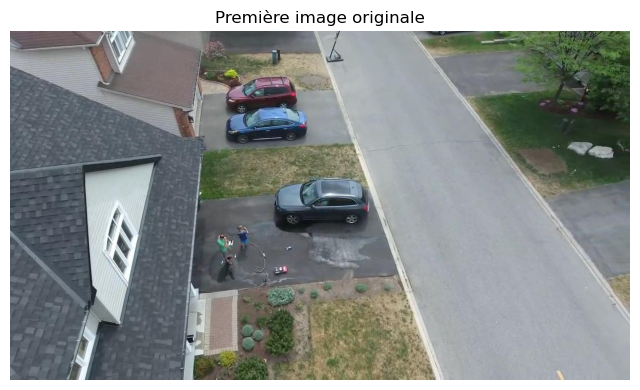

In [4]:
first_image_bgr = None
first_image_rgb = None

if len(image_files) > 0:
    first_image_bgr = cv2.imread(str(image_files[0]))

    if first_image_bgr is not None:
        height, width = first_image_bgr.shape[:2]
        channels = first_image_bgr.shape[2]
        print("Image chargée correctement.")
        print("Hauteur :", height)
        print("Largeur :", width)
        print("Nombre de canaux :", channels)

        first_image_rgb = cv2.cvtColor(first_image_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 5))
        plt.imshow(first_image_rgb)
        plt.title("Première image originale")
        plt.axis("off")
        plt.show()
    else:
        print("La première image n'a pas pu être chargée.")
else:
    print("Aucune image n'est disponible dans le dossier img.")

Cette première image sert de point de départ pour initialiser le suivi de l’objet.

## 5. Visualisation de la bounding box initiale

Nous récupérons la première bounding box du fichier `groundtruth.txt` et nous la dessinons sur la première image.

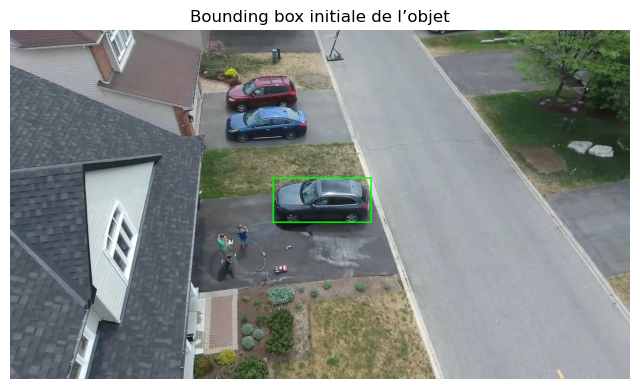

Bounding box initiale : (543, 305, 202, 91)


In [5]:
initial_bbox = None

if first_image_bgr is not None and len(groundtruth) > 0:
    x, y, w, h = groundtruth.iloc[0]
    initial_bbox = (int(x), int(y), int(w), int(h))

    image_with_bbox = first_image_bgr.copy()
    cv2.rectangle(image_with_bbox, (x, y), (x + w, y + h), (0, 255, 0), 2)

    image_with_bbox_rgb = cv2.cvtColor(image_with_bbox, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(image_with_bbox_rgb)
    plt.title("Bounding box initiale de l’objet")
    plt.axis("off")
    plt.show()

    print("Bounding box initiale :", initial_bbox)
else:
    print("Impossible d'afficher la bounding box initiale.")

Nous observons que la bounding box encadre l’objet étudié. Cette zone représente la région initiale dans laquelle nous allons chercher les points caractéristiques.

## 6. Extraction de la région d’intérêt ROI

Nous extrayons maintenant la région d’intérêt, appelée ROI. Elle correspond à la partie de l’image située à l’intérieur de la bounding box initiale.

Taille de la ROI : (91, 202, 3)


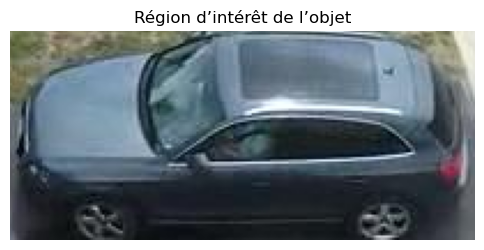

In [6]:
roi = None

if first_image_bgr is not None and initial_bbox is not None:
    x, y, w, h = initial_bbox
    roi = first_image_bgr[y:y + h, x:x + w]

    if roi.size > 0:
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        print("Taille de la ROI :", roi.shape)

        plt.figure(figsize=(6, 4))
        plt.imshow(roi_rgb)
        plt.title("Région d’intérêt de l’objet")
        plt.axis("off")
        plt.show()
    else:
        print("La ROI est vide. Il faut vérifier la bounding box.")
else:
    print("Impossible d'extraire la ROI.")

La région d’intérêt correspond uniquement à l’objet que nous voulons suivre. Cela évite de détecter des points dans l’arrière-plan.

## 7. Prétraitement de la première image

Nous appliquons maintenant le prétraitement défini dans l’étape 02. Si l’import n’est pas disponible, nous utilisons une version simple directement dans le notebook.

Taille de l'image prétraitée : (720, 1280)
L'image prétraitée est bien en niveaux de gris.


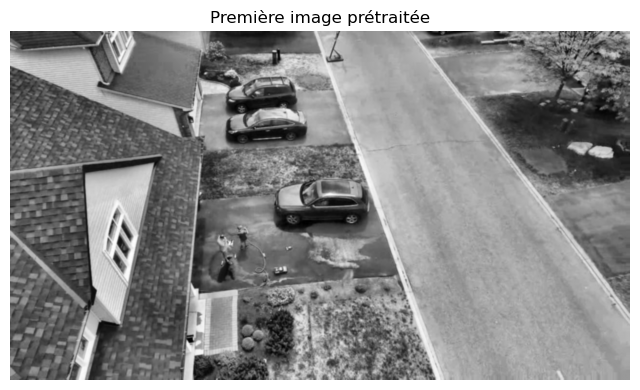

In [7]:
if preprocess_image is None:
    def preprocess_image(image_bgr):
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        preprocessed = cv2.GaussianBlur(enhanced, (5, 5), 0)
        return preprocessed

    print("Version simple de preprocess_image définie dans le notebook.")

preprocessed_image = None

if first_image_bgr is not None:
    preprocessed_image = preprocess_image(first_image_bgr)

    print("Taille de l'image prétraitée :", preprocessed_image.shape)
    if len(preprocessed_image.shape) == 2:
        print("L'image prétraitée est bien en niveaux de gris.")
    else:
        print("Attention : l'image prétraitée n'est pas en niveaux de gris.")

    plt.figure(figsize=(8, 5))
    plt.imshow(preprocessed_image, cmap="gray")
    plt.title("Première image prétraitée")
    plt.axis("off")
    plt.show()
else:
    print("Impossible de prétraiter l'image car elle n'est pas chargée.")

Le prétraitement permet de rendre l’image plus adaptée à la détection des points caractéristiques. Nous gardons une image en niveaux de gris car le flot optique travaille sur les variations d’intensité.

## 8. Détection des points caractéristiques dans la ROI

Nous détectons maintenant des points caractéristiques uniquement dans la ROI. Les coordonnées détectées sont d’abord relatives à la ROI, puis nous les convertissons en coordonnées globales dans l’image.

In [8]:
object_points = None

if preprocessed_image is not None and initial_bbox is not None:
    x, y, w, h = initial_bbox
    roi_gray = preprocessed_image[y:y + h, x:x + w]

    object_points = cv2.goodFeaturesToTrack(
        roi_gray,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    if object_points is not None:
        object_points[:, 0, 0] += x
        object_points[:, 0, 1] += y
        print("Nombre de points détectés dans la ROI :", len(object_points))
    else:
        print("Aucun point caractéristique n'a été détecté dans la ROI.")
else:
    print("Impossible de détecter les points car l'image prétraitée ou la bbox manque.")

Nombre de points détectés dans la ROI : 80


Les points caractéristiques représentent des zones faciles à retrouver dans les images suivantes, comme des coins ou des détails de texture. Ces points seront utilisés plus tard comme entrée de Lucas-Kanade.

## 9. Visualisation des points caractéristiques sur l’objet

Nous affichons maintenant les points détectés sur l’image originale, avec la bounding box initiale. Cette visualisation nous permet de vérifier si les points sont bien situés sur l’objet.

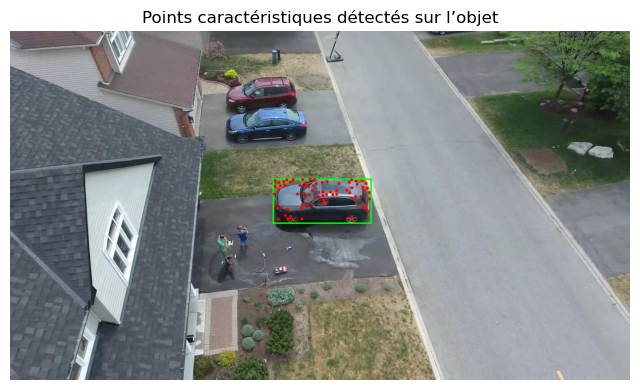

In [9]:
if first_image_bgr is not None and initial_bbox is not None:
    x, y, w, h = initial_bbox
    image_with_points = first_image_bgr.copy()
    cv2.rectangle(image_with_points, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if object_points is not None:
        for point in object_points:
            px, py = point.ravel().astype(int)
            cv2.circle(image_with_points, (px, py), 3, (0, 0, 255), -1)
    else:
        print("Aucun point à dessiner sur l'objet.")

    image_with_points_rgb = cv2.cvtColor(image_with_points, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(image_with_points_rgb)
    plt.title("Points caractéristiques détectés sur l’objet")
    plt.axis("off")
    plt.show()
else:
    print("Impossible d'afficher les points caractéristiques.")

Nous vérifions ici que les points détectés se trouvent bien sur l’objet et non dans l’arrière-plan. Si les points sont bien répartis sur l’objet, le suivi sera plus fiable dans les prochaines étapes.

## 10. Comparaison : points détectés dans toute l’image vs dans la ROI

Nous comparons la détection de points dans toute l’image avec la détection limitée à la ROI. Cette comparaison montre pourquoi nous préférons initialiser les points directement sur l’objet.

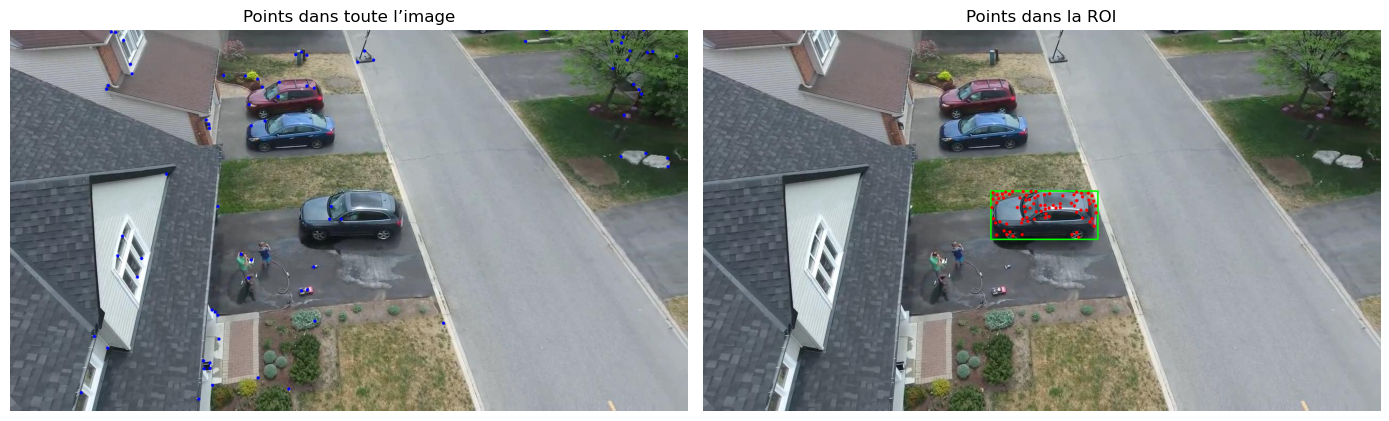

In [10]:
if first_image_bgr is not None and preprocessed_image is not None:
    all_image_points = cv2.goodFeaturesToTrack(
        preprocessed_image,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    image_all_points = first_image_bgr.copy()
    image_roi_points = first_image_bgr.copy()

    if all_image_points is not None:
        for point in all_image_points:
            px, py = point.ravel().astype(int)
            cv2.circle(image_all_points, (px, py), 3, (255, 0, 0), -1)

    if initial_bbox is not None:
        x, y, w, h = initial_bbox
        cv2.rectangle(image_roi_points, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if object_points is not None:
        for point in object_points:
            px, py = point.ravel().astype(int)
            cv2.circle(image_roi_points, (px, py), 3, (0, 0, 255), -1)

    image_all_points_rgb = cv2.cvtColor(image_all_points, cv2.COLOR_BGR2RGB)
    image_roi_points_rgb = cv2.cvtColor(image_roi_points, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(image_all_points_rgb)
    axes[0].set_title("Points dans toute l’image")
    axes[0].axis("off")

    axes[1].imshow(image_roi_points_rgb)
    axes[1].set_title("Points dans la ROI")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Impossible de comparer les points car une image manque.")

Lorsque nous détectons les points dans toute l’image, plusieurs points peuvent appartenir à l’arrière-plan. Pour notre projet, nous voulons suivre un seul objet. C’est pourquoi nous limitons la détection à la région d’intérêt.

## 11. Création d’une fonction simple d’initialisation

Nous regroupons maintenant les étapes principales dans une fonction simple. Cette fonction prépare l’image et retourne les points caractéristiques de l’objet en coordonnées globales.

In [11]:
def initialize_object_points(image_bgr, bbox):
    """
    Initialise les points caractéristiques de l’objet à suivre.
    Entrée :
    - image_bgr : première image en couleur
    - bbox : bounding box initiale (x, y, w, h)

    Sortie :
    - points : points caractéristiques en coordonnées globales
    - preprocessed : image prétraitée en niveaux de gris
    """
    x, y, w, h = bbox

    preprocessed = preprocess_image(image_bgr)
    roi_gray = preprocessed[y:y + h, x:x + w]

    points = cv2.goodFeaturesToTrack(
        roi_gray,
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    if points is not None:
        points[:, 0, 0] += x
        points[:, 0, 1] += y

    return points, preprocessed

Nous testons maintenant cette fonction sur la première image et la bounding box initiale.

In [12]:
if first_image_bgr is not None and initial_bbox is not None:
    test_points, test_preprocessed = initialize_object_points(first_image_bgr, initial_bbox)

    if test_points is not None:
        print("Nombre de points retournés par la fonction :", len(test_points))
    else:
        print("La fonction n'a détecté aucun point.")

    print("Taille de l'image prétraitée retournée :", test_preprocessed.shape)
else:
    print("Impossible de tester la fonction d'initialisation.")

Nombre de points retournés par la fonction : 80
Taille de l'image prétraitée retournée : (720, 1280)


## 12. Conclusion de l’étape d’initialisation

Dans cette étape, nous avons initialisé l’objet à suivre à partir de la première bounding box du fichier `groundtruth`. Nous avons extrait la région d’intérêt correspondant à l’objet, puis nous avons détecté des points caractéristiques dans cette zone. Ces points serviront d’entrée à la méthode de Lucas-Kanade dans l’étape suivante.

Nous observons que cette étape reste simple et cohérente avec l’objectif du projet : préparer uniquement l’objet à suivre, sans encore faire de tracking complet, de trajectoire, de vitesse ou de direction.